In [3]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import shutil, random
import cv2
from ultralytics import YOLO

### Datasets Report

In [8]:
from src.exploration import DatasetExplorer


DATASET: data/ARMA-3.v8i.yolo26
images: 583
labels: 583
classes: ['Anti-air Defence', 'Battle-Tank', 'Logistics-Vehicle', 'M2A4-Slammer', 'Mobile-Radar']

objects per class:
  Anti-air Defence: 348
  Battle-Tank: 298
  Logistics-Vehicle: 322
  M2A4-Slammer: 330
  Mobile-Radar: 231


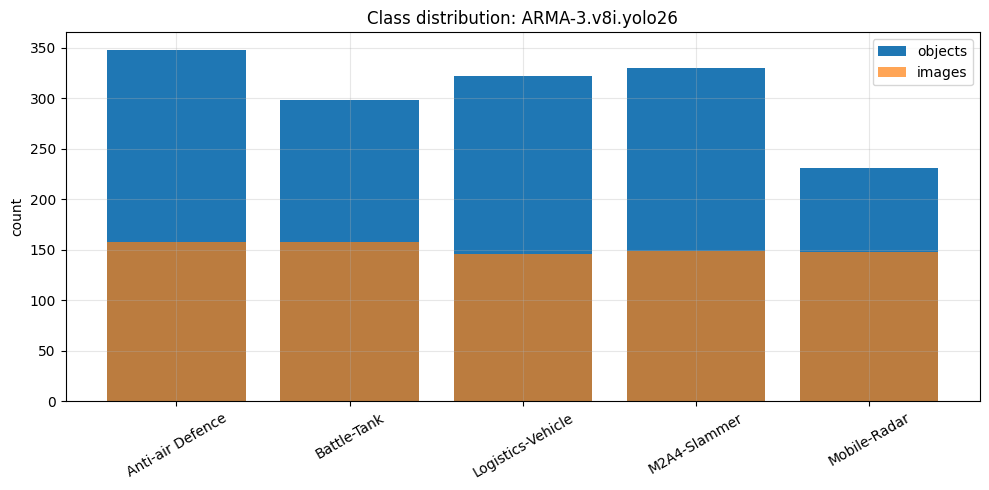

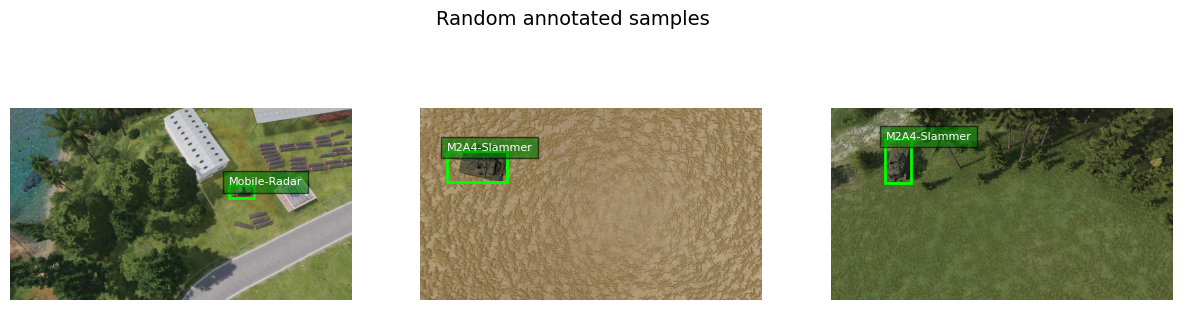


DATASET: data/ArmaCV_dataset_yolo26
images: 363
labels: 363
classes: ['marid', 'varsuk', 'zamak']

objects per class:
  marid: 180
  varsuk: 157
  zamak: 159


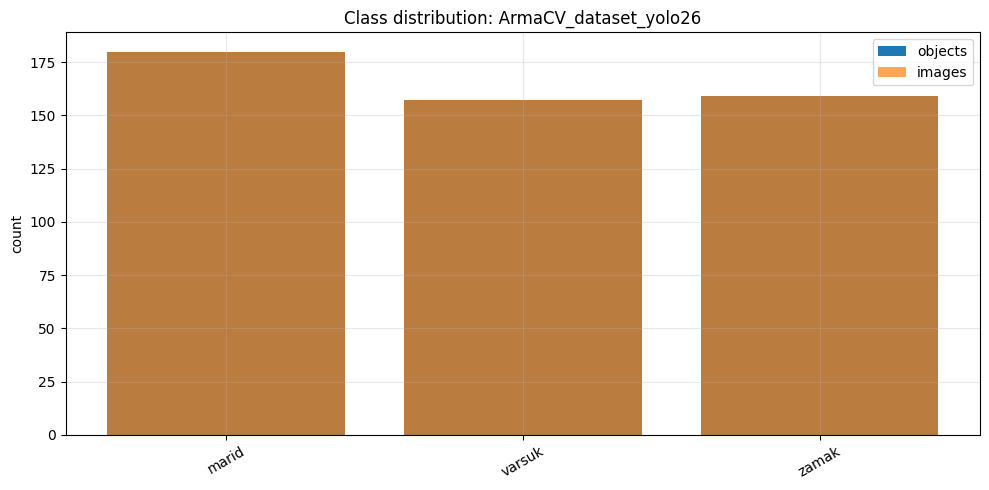

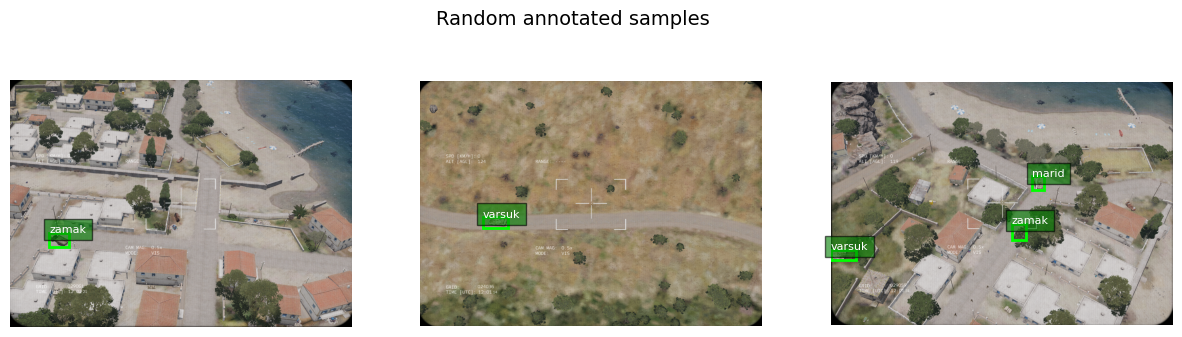

In [10]:
explorer = DatasetExplorer(
    [
        "./data/ARMA-3.v8i.yolo26",
        "./data/ArmaCV_dataset_yolo26"
    ],
    plot=True,
    plot_samples=True,
    sample_count=3
)

reports = explorer.run()

### Merge Datasets

In [ ]:
from src.merge_datasets import DatasetMerger

In [ ]:
class_mapping = {
    "tracked_armored": ["Battle-Tank", "M2A4-Slammer", "varsuk"],
    "wheeled_vehicle": ["Logistics-Vehicle", "marid", "zamak"],
    "support_system": ["Anti-air Defence", "Mobile-Radar"],
}

merger = DatasetMerger(
    dataset_paths=[
        "./data/ARMA-3.v8i.yolo26",
        "./data/ArmaCV_dataset_yolo26",
    ],
    output_dir="./data/combined_vehicle_groups",
    class_mapping=class_mapping,
    split=True,
    split_ratio=(0.8, 0.1, 0.1),
    seed=42,
)

merger.run()

Done. Output saved to: data/combined_vehicle_groups
Classes: ['tracked_armored', 'wheeled_vehicle', 'support_system']
Total images: 946
Train: 756
Val:   94
Test:  96


### Model Fine Tunning

In [11]:
model = YOLO("yolo26l.pt")

In [12]:
model.train(
    data="./data/combined_vehicle_groups/data.yaml",
    epochs=15,
    imgsz=640,
    batch=8,
    device=0,
    workers=0,
    project="runs_yolo26",
    name="arma_asset"
)

New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/combined_vehicle_groups/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, mul

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a809692a080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [13]:
def run_yolo_on_video(model_path, video_path, output_path, conf=0.25):
    model = YOLO(model_path)

    results = model.predict(
        source=video_path,
        conf=conf,
        save=False,
        stream=True
    )

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    for r in results:
        frame = r.plot()   # draws boxes + labels
        writer.write(frame)

    writer.release()
    print(f"Saved to: {output_path}")

In [14]:
run_yolo_on_video(
    model_path="./runs/detect/runs_yolo26/arma_asset/weights/best.pt",
    video_path="./test_video/sample.mp4",
    output_path="./test_video/sample_labeled.mp4",
    conf=0.55
)


video 1/1 (frame 1/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 43.7ms
video 1/1 (frame 2/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 15.4ms
video 1/1 (frame 3/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 13.5ms
video 1/1 (frame 4/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 14.8ms
video 1/1 (frame 5/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 14.1ms
video 1/1 (frame 6/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 12.6ms
video 1/1 (frame 7/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 (no detections), 15.6ms
video 1/1 (frame 8/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 1 wheeled_vehicle, 13.4ms
video 1/1 (frame 9/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 1 wheeled_vehicle, 13.2ms
video 1/1 (frame 10/6612) /mnt/e/Desk/SIB/test_video/sample.mp4: 384x640 1 wheeled_vehicle, 13.9ms
video 1/1 (frame 11/6612) /mnt/e